**Анализ временных рядов:**
1. Проанализируйте тенденцию создания сделок с течением времени и их связь
с звонками.
2. Изучите распределение времени закрытия сделок и продолжительность
периода от создания до закрытия.

Анализ тенденции создания сделок (deals_f_clean)

Посмотрим, как менялось количество сделок с течением времени:

- динамика по дням / месяцам;

- возможно, сезонность (по неделям, месяцам, кварталам)

/tmp/ipython-input-3406196766.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  deals.groupby(pd.Grouper(key="Created Time", freq="M"))
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


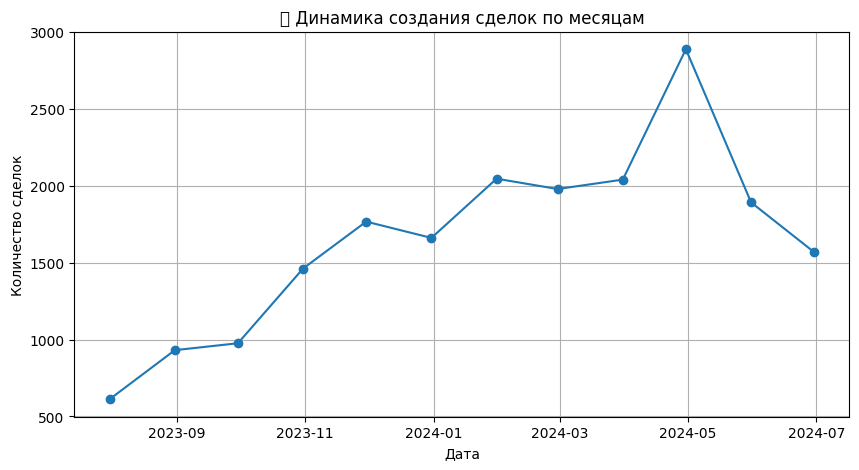

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ===  Загружаем данные ===
calls = pd.read_excel("Calls_f_clean.xlsx", dtype={"CONTACTID": str})
deals = pd.read_excel("Deals_f_clean.xlsx", dtype={"Id": str,"Contact Name": str})

# ===  Анализ тенденции создания сделок ===  (на 1 этапе перевели уже в нужный формат)
#deals["Created Time"] = pd.to_datetime(deals["Created Time"], errors="coerce")

# группируем по месяцу
deals_monthly = (
    deals.groupby(pd.Grouper(key="Created Time", freq="M"))
    .size()
    .reset_index(name="Deals_Count")
)

# график динамики сделок
plt.figure(figsize=(10,5))
plt.plot(deals_monthly["Created Time"], deals_monthly["Deals_Count"], marker="o")
plt.title("📈 Динамика создания сделок по месяцам")
plt.xlabel("Дата")
plt.ylabel("Количество сделок")
plt.grid(True)
plt.show()

Теперь посмотрим на звонки.

/tmp/ipython-input-2790774352.py:5: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128222 (\N{TELEPHONE RECEIVER}) missing from font(s) DejaVu Sans.



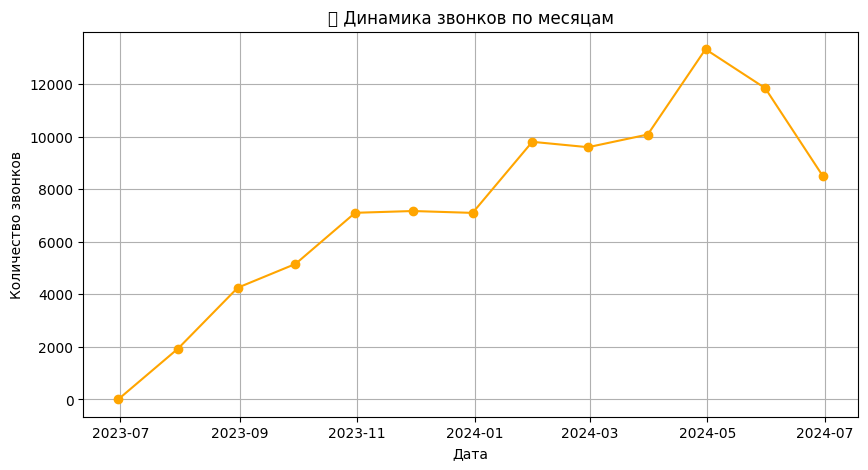

In [ ]:
# ===  Анализ звонков === (в формат перевели ранее)
#calls["Call Start Time"] = pd.to_datetime(calls["Call Start Time"], errors="coerce")

calls_monthly = (
    calls.groupby(pd.Grouper(key="Call Start Time", freq="M"))
    .size()
    .reset_index(name="Calls_Count")
)

plt.figure(figsize=(10,5))
plt.plot(calls_monthly["Call Start Time"], calls_monthly["Calls_Count"], color="orange", marker="o")
plt.title("📞 Динамика звонков по месяцам")
plt.xlabel("Дата")
plt.ylabel("Количество звонков")
plt.grid(True)
plt.show()

Сделаем обьединенный график. Гипотеза - есть связь (кореляция) между количеством звонков и сделок.

In [ ]:
import plotly.graph_objects as go

# ===  Группируем по месяцам ===
calls_monthly2 = (
    calls.groupby(pd.Grouper(key="Call Start Time", freq="M"))
    .size()
    .reset_index(name="Calls_Count")
    .rename(columns={"Call Start Time": "Month"})
)

deals_monthly2 = (
    deals.groupby(pd.Grouper(key="Created Time", freq="M"))
    .size()
    .reset_index(name="Deals_Count")
    .rename(columns={"Created Time": "Month"})
)

# ===  Объединяем по месяцу ===
merged = pd.merge(calls_monthly2, deals_monthly2, on="Month", how="outer").fillna(0)

# ===  Создаем интерактивный график ===
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=merged["Month"],
    y=merged["Calls_Count"],
    mode="lines+markers",
    name="📞 Звонки",
    line=dict(color="orange", width=3),
    marker=dict(size=6)
))

fig.add_trace(go.Scatter(
    x=merged["Month"],
    y=merged["Deals_Count"],
    mode="lines+markers",
    name="💼 Сделки",
    line=dict(color="royalblue", width=3),
    marker=dict(size=6)
))

# ===  Настраиваем оформление ===
fig.update_layout(
    title="📈 Динамика звонков и сделок по месяцам",
    xaxis_title="Месяц",
    yaxis_title="Количество",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
)

fig.show()


/tmp/ipython-input-825518710.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  calls.groupby(pd.Grouper(key="Call Start Time", freq="M"))
/tmp/ipython-input-825518710.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  deals.groupby(pd.Grouper(key="Created Time", freq="M"))


In [ ]:
# ===  Считаем корреляцию ===
corr = merged["Calls_Count"].corr(merged["Deals_Count"])
print(f"Корреляция между количеством звонков и сделок: {corr:.2f}")

Корреляция между количеством звонков и сделок: 0.96


Гипотеза подтвердилась.

In [ ]:
fig.write_json("calls_deals_trend.json")

Почему такое изменение сделок? Гипотеза - просто сезонность. Посмотрим на изменениие в рекламе - в показах и кликах.

In [2]:
spend_df = pd.read_excel("Spend_f_clean.xlsx")

In [3]:
import pandas as pd

# Убедимся, что поле Date в формате datetime
spend_df["Date"] = pd.to_datetime(spend_df["Date"], errors="coerce")

# Добавляем столбец с месяцем в формате "YYYY-MM"
spend_df["Month"] = spend_df["Date"].dt.to_period("M").astype(str)

# Агрегируем по месяцам
monthly_stats = (
    spend_df.groupby("Month")[["Impressions", "Spend", "Clicks"]]
    .sum()
    .reset_index()
    .sort_values("Month")
)

# Настройки отображения
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

print(monthly_stats.to_string(index=False))


  Month  Impressions    Spend  Clicks
2023-07      1868812  6062.32   23553
2023-08      3506308  9033.73   35346
2023-09      5554229  8711.16   49103
2023-10      4028456 11807.78   50047
2023-11      2214167 10890.74   34108
2023-12      3598888 12186.03   42426
2024-01      4388750 12583.57   44298
2024-02      3609747 12476.83   40407
2024-03      4572666 16223.38   42920
2024-04      8463518 20964.65   61601
2024-05      5042908 17212.31   44768
2024-06      4230561 11370.95   29878


In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- создаем 3 сабплота в ряд ---
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("📈 Impressions", "💰 Spend", "🖱 Clicks"),
    horizontal_spacing=0.08
)

# --- первый график: Impressions ---
fig.add_trace(
    go.Scatter(
        x=monthly_stats["Month"],
        y=monthly_stats["Impressions"],
        mode="lines+markers",
        name="Impressions",
        line=dict(color="#1f77b4", width=2),
        marker=dict(size=6),
        text=monthly_stats["Impressions"],
        hovertemplate="Month: %{x}<br>Impressions: %{y}<extra></extra>"
    ),
    row=1, col=1
)

# --- второй график: Spend ---
fig.add_trace(
    go.Scatter(
        x=monthly_stats["Month"],
        y=monthly_stats["Spend"],
        mode="lines+markers",
        name="Spend",
        line=dict(color="#2ca02c", width=2),
        marker=dict(size=6),
        text=monthly_stats["Spend"].round(2),
        hovertemplate="Month: %{x}<br>Spend: %{y}<extra></extra>"
    ),
    row=1, col=2
)

# --- третий график: Clicks ---
fig.add_trace(
    go.Scatter(
        x=monthly_stats["Month"],
        y=monthly_stats["Clicks"],
        mode="lines+markers",
        name="Clicks",
        line=dict(color="#ff7f0e", width=2),
        marker=dict(size=6),
        text=monthly_stats["Clicks"],
        hovertemplate="Month: %{x}<br>Clicks: %{y}<extra></extra>"
    ),
    row=1, col=3
)

# --- оформление ---
fig.update_layout(
    title_text="📊 Динамика Impressions, Spend и Clicks по месяцам",
    showlegend=False,
    height=500,
    width=1100,
    plot_bgcolor="white",
    title_x=0.5
)

# оси X для всех графиков
fig.update_xaxes(title_text="Month", tickangle=45)

# оси Y индивидуально
fig.update_yaxes(title_text="Impressions", row=1, col=1)
fig.update_yaxes(title_text="Spend", row=1, col=2)
fig.update_yaxes(title_text="Clicks", row=1, col=3)

fig.show()


In [12]:
fig.write_json("time_spend.json")

Посчитаем кореляцию между количеством сделок и марктинговыми показателями.

In [6]:
import pandas as pd

# --- 1. Приведём формат месяца к единому виду (YYYY-MM) ---
deals_monthly["Month"] = pd.to_datetime(deals_monthly["Created Time"]).dt.to_period("M").astype(str)
monthly_stats["Month"] = pd.to_datetime(monthly_stats["Month"]).dt.to_period("M").astype(str)

# --- 2. Объединяем по месяцу ---
merged = pd.merge(deals_monthly, monthly_stats, on="Month", how="inner")

# --- 3. Считаем корреляции ---
corr_impressions = merged["Deals_Count"].corr(merged["Impressions"])
corr_spend = merged["Deals_Count"].corr(merged["Spend"])
corr_clicks = merged["Deals_Count"].corr(merged["Clicks"])

# --- 4. Выводим результат ---
print("📈 Корреляция количества сделок с маркетинговыми метриками:")
print(f"• Impressions: {corr_impressions:.3f}")
print(f"• Spend:       {corr_spend:.3f}")
print(f"• Clicks:      {corr_clicks:.3f}")


📈 Корреляция количества сделок с маркетинговыми метриками:
• Impressions: 0.642
• Spend:       0.914
• Clicks:      0.643


Вывод - имеет место максимальная кореляция количества сделок в затратами на привлечение клиентов. А вот уже почему так менялись эти затраты со временем? Возможно из-за сезонности, но это вопрос к маркетинговому отделу.

2. Изучите распределение времени закрытия сделок и продолжительность
периода от создания до закрытия.

In [ ]:
import plotly.express as px

#  Фильтруем успешные сделки
deals_success = deals[deals["Stage"] == "Payment Done"].copy()

#  Преобразуем даты в datetime
deals_success["Created Time"] = pd.to_datetime(deals_success["Created Time"], errors="coerce")
deals_success["Closing Date"] = pd.to_datetime(deals_success["Closing Date"], errors="coerce")

#  Считаем длительность цикла сделки в днях
deals_success["Days_to_Close"] = (deals_success["Closing Date"] - deals_success["Created Time"]).dt.days

#  Убираем отрицательные и пустые значения
deals_success = deals_success[deals_success["Days_to_Close"].notna() & (deals_success["Days_to_Close"] >= 0)]



In [ ]:

# Вычисляем сводную статистику
mean_days = deals_success["Days_to_Close"].mean()
median_days = deals_success["Days_to_Close"].median()
min_days = deals_success["Days_to_Close"].min()
max_days = deals_success["Days_to_Close"].max()


print(f"Среднее: {mean_days:.1f} дней")
print(f"Медиана: {median_days} дней")
print(f"Минимум: {min_days} дней")
print(f"Максимум: {max_days} дней")



Среднее: 34.0 дней
Медиана: 17.0 дней
Минимум: 0.0 дней
Максимум: 304.0 дней


In [ ]:


# Построение гистограммы
fig = px.histogram(
    deals_success,
    x="Days_to_Close",
    nbins=30,
    title="⏳ Распределение времени от создания сделки до закрытия (успешные сделки)",
    labels={"Days_to_Close": "Дней до закрытия сделки"},
    color_discrete_sequence=["#2E91E5"]
)

# Текст с основными статистиками
stats_text = f"""
Минимум: {min_days} дней<br>
Максимум: {max_days} дней<br>
Среднее: {mean_days:.1f} дней<br>
Медиана: {median_days} дней
"""

# Добавляем аннотацию в верхний правый угол графика
fig.add_annotation(
    xref="paper", yref="paper",  # координаты в относительных единицах графика
    x=0.95, y=0.95,
    text=stats_text,
    showarrow=False,
    align="right",
    bordercolor="black",
    borderwidth=1,
    borderpad=4,
    bgcolor="white",
    opacity=0.8
)

fig.update_layout(
    xaxis_title="Количество дней",
    yaxis_title="Количество сделок",
    bargap=0.1
)

fig.show()


Посмотрим распределение сделок, которые закрылись за период до 100 дней.

In [ ]:
# Фильтруем сделки до 100 дней
deals_short = deals_success[deals_success["Days_to_Close"] <= 100]


# Строим гистограмму
fig_short = px.histogram(
    deals_short,
    x="Days_to_Close",
    nbins=30,
    title="⏳ Распределение времени закрытия сделок до 100 дней",
    labels={"Days_to_Close": "Дней до закрытия сделки"},
    color_discrete_sequence=["#2E91E5"]
)



fig_short.update_layout(
    xaxis_title="Количество дней",
    yaxis_title="Количество сделок",
    bargap=0.1
)

fig_short.show()


В целом видим, что большинство сделок (успешных) закрывается в период до 34 дней. Но при этом есть еденичные сделки, которые закрываются очень долго, вплоть о года.

In [ ]:
import plotly.express as px

# Считаем количество сделок по каждому числу дней
days_count = deals_success["Days_to_Close"].value_counts().sort_index()

# Преобразуем в DataFrame для Plotly
df_line = days_count.reset_index()
df_line.columns = ["Days_to_Close", "Deals_Count"]

# Строим линию
fig_line = px.line(
    df_line,
    x="Days_to_Close",
    y="Deals_Count",
    title="⏳ Распределение времени от создания сделки до закрытия (успешные сделки)",
    labels={"Days_to_Close": "Дней до закрытия сделки", "Deals_Count": "Количество сделок"},
    markers=True  # чтобы показать точки
)

# Добавляем текст со статистикой
stats_text = f"""
Минимум: {min_days} дней<br>
Максимум: {max_days} дней<br>
Среднее: {mean_days:.1f} дней<br>
Медиана: {median_days} дней
"""
fig_line.add_annotation(
    xref="paper", yref="paper",
    x=0.95, y=0.95,
    text=stats_text,
    showarrow=False,
    align="right",
    bordercolor="black",
    borderwidth=1,
    borderpad=4,
    bgcolor="white",
    opacity=0.8
)

fig_line.update_layout(
    xaxis_title="Количество дней",
    yaxis_title="Количество сделок"
)

fig_line.show()


In [ ]:
fig.write_json("deals_lenth.json")

In [13]:
import pandas as pd
import plotly.graph_objects as go

# --- 1. Преобразуем даты в формат месяца ---
deals["Created Month"] = pd.to_datetime(deals["Created Time"], errors="coerce").dt.to_period("M").astype(str)
deals["Closed Month"] = pd.to_datetime(deals["Closing Date"], errors="coerce").dt.to_period("M").astype(str)

# --- 2. Группировка по месяцам ---
created = deals.groupby("Created Month")["Id"].count().reset_index(name="Created Deals")

closed = (
    deals.loc[deals["Stage"] == "Payment Done"]
    .groupby("Closed Month")["Id"]
    .count()
    .reset_index(name="Closed Deals")
)

# --- 3. Объединяем и сортируем ---
monthly_deals = pd.merge(
    created, closed, left_on="Created Month", right_on="Closed Month", how="outer"
).fillna(0)

monthly_deals["Month"] = monthly_deals["Created Month"].combine_first(monthly_deals["Closed Month"])
monthly_deals["Month"] = pd.to_datetime(monthly_deals["Month"], format="%Y-%m", errors="coerce")
monthly_deals = monthly_deals.sort_values("Month")

# --- 4. Строим график с двумя осями ---
fig2 = go.Figure()

# Левая ось — созданные сделки
fig2.add_trace(go.Bar(
    x=monthly_deals["Month"],
    y=monthly_deals["Created Deals"],
    name="Созданные сделки",
    marker_color="#2E91E5",
    opacity=0.7,
    yaxis="y1"
))

# Правая ось — закрытые сделки
fig2.add_trace(go.Scatter(
    x=monthly_deals["Month"],
    y=monthly_deals["Closed Deals"],
    name="Закрытые сделки (успешные)",
    mode="lines+markers",
    line=dict(color="#00C49F", width=3),
    yaxis="y2"
))

# --- 5. Настройка осей ---
fig2.update_layout(
    title="📊 Созданные и успешно закрытые сделки по месяцам",
    xaxis=dict(title="Месяц"),
    yaxis=dict(
        title="Созданные сделки",
        titlefont=dict(color="#2E91E5"),
        tickfont=dict(color="#2E91E5")
    ),
    yaxis2=dict(
        title="Закрытые сделки (успешные)",
        titlefont=dict(color="#00C49F"),
        tickfont=dict(color="#00C49F"),
        overlaying="y",
        side="right"
    ),
    legend=dict(x=0.5, y=-0.2, orientation="h"),
    template="plotly_white",
    bargap=0.3,
    hovermode="x unified"
)

fig2.show()


In [14]:
fig2.write_json("open_closed.json")